In [126]:
import pandas as pd # usado para trabajar dataframes
import numpy as np # usado para trabajar arrays


import matplotlib.pyplot as plt
import sklearn
from sklearn import preprocessing
from sklearn.svm import SVC
from sklearn.datasets import make_blobs
from sklearn import model_selection
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report,accuracy_score, confusion_matrix
from pandas.plotting import scatter_matrix
import seaborn as sns

**Lectura del Archivo**

In [2]:
from google.colab import files
load = files.upload()

Saving cancer_mama.csv.CSV to cancer_mama.csv.CSV


Leemos el archivo y mostramos la cabecera del mismo

In [3]:
df = pd.read_csv('cancer_mama.csv.CSV')

In [4]:
df.head()

,Id,Clump_thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


Variables de interes:

*   Class: si el cáncer es benigno representado con el valor 2 o con 4 si es maligno.



Compruebo los tipos de datos de mi Data Frame

In [5]:
df.dtypes

Id                              int64
Clump_thickness                 int64
Uniformity_Cell_Size            int64
Uniformity_Cell_Shape           int64
Marginal_Adhesion               int64
Single_Epithelial_Cell_Size     int64
Bare_Nuclei                    object
Bland_Chromatin                 int64
Normal_Nucleoli                 int64
Mitoses                         int64
Class                           int64
dtype: object

Al notar que la columna Bare_Nuclei contiene datos de tipo object decido revisarla para comprobar

In [6]:
df.Bare_Nuclei

0       1
1      10
2       2
3       4
4       1
       ..
694     2
695     1
696     3
697     4
698     5
Name: Bare_Nuclei, Length: 699, dtype: object

Al comprobar el tipo de dato de la columna utilizo la funcion astype() para modificar dicho dato por el que necesito, pero al hacerlo el programa me dice que no es posible ya que hay datos que son de tipo string por lo tanto no puede transformarlos a float.

In [7]:
df.Bare_Nuclei = df.Bare_Nuclei.astype('float')

ValueError: ignored

Para solucionar provisoriamente esto tranformaré esos datos de tipo string a datos null

In [8]:
from pandas.core.groupby.groupby import nullcontext
df.Bare_Nuclei = df.Bare_Nuclei.str.replace('?', nullcontext, regex=True)

In [9]:
df.Bare_Nuclei

0       1
1      10
2       2
3       4
4       1
       ..
694     2
695     1
696     3
697     4
698     5
Name: Bare_Nuclei, Length: 699, dtype: object

In [10]:
df.Bare_Nuclei = df.Bare_Nuclei.astype('float')

In [11]:
df.Bare_Nuclei

0       1.0
1      10.0
2       2.0
3       4.0
4       1.0
       ... 
694     2.0
695     1.0
696     3.0
697     4.0
698     5.0
Name: Bare_Nuclei, Length: 699, dtype: float64

Verifico la cantidad de valores nulos en mi data frame

In [12]:
df.isnull().sum()

Id                              0
Clump_thickness                 0
Uniformity_Cell_Size            0
Uniformity_Cell_Shape           0
Marginal_Adhesion               0
Single_Epithelial_Cell_Size     0
Bare_Nuclei                    16
Bland_Chromatin                 0
Normal_Nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64

Para evitar problemas, ya que los valores son mínimos, directamente eliminamos la columna. Además la columna Id no es significativa por lo tanto la eliminaremos de nuestro DF

In [92]:
df.drop('Bare_Nuclei',axis = 1,inplace = True)

In [93]:
df.isnull().sum()

Clump_thickness                0
Uniformity_Cell_Size           0
Uniformity_Cell_Shape          0
Marginal_Adhesion              0
Single_Epithelial_Cell_Size    0
Bland_Chromatin                0
Normal_Nucleoli                0
Mitoses                        0
Class                          0
dtype: int64

Revisamos las actuales columnas del DF y a su vez revisamos la cantidad de datos de cada una de ellas

In [95]:
df.columns

Index(['Clump_thickness', 'Uniformity_Cell_Size', 'Uniformity_Cell_Shape',
       'Marginal_Adhesion', 'Single_Epithelial_Cell_Size', 'Bland_Chromatin',
       'Normal_Nucleoli', 'Mitoses', 'Class'],
      dtype='object')

In [96]:
for x in df.columns:
  print(df[x].count())

699
699
699
699
699
699
699
699
699


# Variables Categoricas

Imprimimos el número total de elementos únicos en cada columna lo que nos permite observar que nuestras 10 variables son variables categóricas, 9 de ellas independientes. La restante es la variable class, que es la que buscaremos pronosticar ya que es la variable dependiente donde se identifica si el tumor es maligno o benigno.

In [97]:
for x in df.columns:
  print(df[x].nunique())

10
10
10
10
10
10
10
9
2


In [98]:
df.Class

0      2
1      2
2      2
3      2
4      2
      ..
694    2
695    2
696    4
697    4
698    4
Name: Class, Length: 699, dtype: int64

Variables Numéricas

In [99]:
df.describe()

,Clump_thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
count,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000
mean,4.417740,3.134478,3.207439,2.806867,3.216023,3.437768,2.866953,1.589413,2.689557
std,2.815741,3.051459,2.971913,2.855379,2.214300,2.438364,3.053634,1.715078,0.951273
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,2.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,3.000000,1.000000,1.000000,2.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,5.000000,4.000000,1.000000,4.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


Podemos decir que hay mayor cantidad de casos benignos ya que la media de Class se encuentra más cerca de 2.
También podemos observar que la variable de salida Class es discreta.

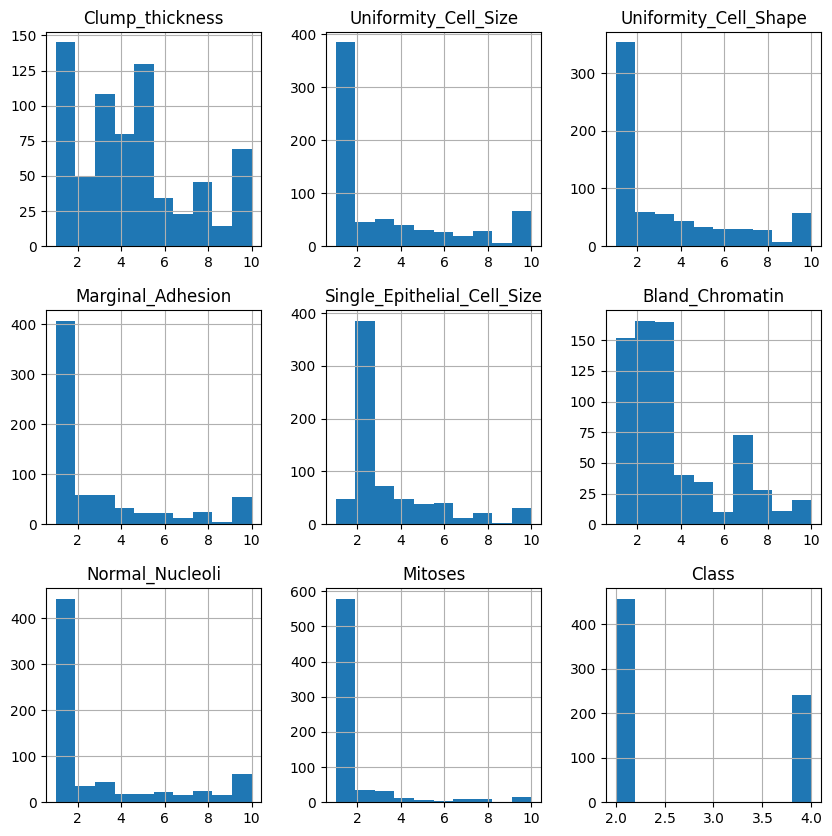

In [100]:
df.hist(figsize = (10,10))
plt.show()

Al representar la distribución de los datos en su histograma podemos notar que la mayoría de las variables se encuentran sesgadas hacia la derecha excepto por la variable Clump_thikness ya que ésta tiene una distribución mas uniforme.

In [101]:
X = df.drop('Class', 1)
y = df['Class']

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.25)

<ipython-input-101-1497e29b1c75>:1: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  X = df.drop('Class', 1)


# Entrenamiento de modelo SVM

Hiperparametros a considerar:


*   C: número de penalización
*   Kernel



Creamos el clasificador y definimos su Hiperparametro

In [109]:
model = SVC(C=1 , kernel='poly')

Entrenamos los modelos

In [110]:
model.fit(X_train,y_train)

SVC(C=1, kernel='poly')

Evaluamos Score

In [111]:
model.score(X_train, y_train)

0.9675572519083969

Comprobamos el score con los datos de prueba

In [112]:
model.score(X_test, y_test)

0.9657142857142857

In [130]:
a = SVC().fit(X_train,y_train) # Ajustamos el modelo.
predictions = a.predict(X_test) # Predecimos el conjunto de prueba.
print(accuracy_score(y_test,predictions)) # Calculamos el accuracy.
print(classification_report(y_test,predictions)) # Generamos informe de clasificación.

0.9714285714285714
              precision    recall  f1-score   support

           2       0.97      0.98      0.98       112
           4       0.97      0.95      0.96        63

    accuracy                           0.97       175
   macro avg       0.97      0.97      0.97       175
weighted avg       0.97      0.97      0.97       175



El accuracy del modelo nos da 0.971

#Realizamos la predicción con el modelo entrenado

 Clump Thickness = 1,
 Uniformity of cell size = 2,
 Uniformity of cell shape = 2,
 Marginal adhesion = 5,
 Single epithelial cell size = 3,
 Bland chromatin = 6,
 Normal nucleoli = 4,
 Mitosis = 8

In [131]:
prediction = a.predict(np.array([[1,2,2,5,3,6,4,8]]))
print(prediction)

[4]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


El valor predicho de Class es 4, lo que sería un tumor maligno.